# Feature Engineering

## Load Python Libraries

In [19]:
# Load Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

## Load Weekly Clinic Dataset

In [20]:
# Load Weekly Dataset
df = pd.read_csv(r"c:\Users\earlc\Amdari\Week 2\roughwork\nexora_care_flow\data\processed\weekly_clinic_appointments.csv")
df['WeekStart'] = pd.to_datetime(df['WeekStart'])
df = df.sort_values(['ClinicID', 'WeekStart']).reset_index(drop=True)

print(f"Loaded {len(df):,} weekly records across {df['ClinicName'].nunique()} clinics.")
df.head()

Loaded 395 weekly records across 4 clinics.


,ClinicID,ClinicName,WeekStart,TotalScheduled,Year,Month
0,1,Nexora Care - Riverside,2024-01-01,269,2024,1
1,1,Nexora Care - Riverside,2024-01-08,316,2024,1
2,1,Nexora Care - Riverside,2024-01-15,261,2024,1
3,1,Nexora Care - Riverside,2024-01-22,284,2024,1
4,1,Nexora Care - Riverside,2024-01-29,283,2024,1


In [21]:
# Create Lag Features per Clinic
df['lag_1w'] = df.groupby('ClinicID')['TotalScheduled'].shift(1)
df['lag_2w'] = df.groupby('ClinicID')['TotalScheduled'].shift(2)
df['lag_4w'] = df.groupby('ClinicID')['TotalScheduled'].shift(4)

df[['ClinicName', 'WeekStart', 'TotalScheduled', 'lag_1w', 'lag_2w', 'lag_4w']].head(7)

,ClinicName,WeekStart,TotalScheduled,lag_1w,lag_2w,lag_4w
0,Nexora Care - Riverside,2024-01-01,269,NaN,NaN,NaN
1,Nexora Care - Riverside,2024-01-08,316,269.0,NaN,NaN
2,Nexora Care - Riverside,2024-01-15,261,316.0,269.0,NaN
3,Nexora Care - Riverside,2024-01-22,284,261.0,316.0,NaN
4,Nexora Care - Riverside,2024-01-29,283,284.0,261.0,269.0
5,Nexora Care - Riverside,2024-02-05,321,283.0,284.0,316.0
6,Nexora Care - Riverside,2024-02-12,322,321.0,283.0,261.0


In [22]:
# Create 4-Week Rolling Average per Clinic
df['rolling_mean_4w'] = df.groupby('ClinicID')['TotalScheduled'].shift(1).rolling(window=4).mean()

df[['ClinicName', 'WeekStart', 'TotalScheduled', 'lag_1w', 'rolling_mean_4w']].head(8)


,ClinicName,WeekStart,TotalScheduled,lag_1w,rolling_mean_4w
0,Nexora Care - Riverside,2024-01-01,269,NaN,NaN
1,Nexora Care - Riverside,2024-01-08,316,269.0,NaN
2,Nexora Care - Riverside,2024-01-15,261,316.0,NaN
3,Nexora Care - Riverside,2024-01-22,284,261.0,NaN
4,Nexora Care - Riverside,2024-01-29,283,284.0,282.50
5,Nexora Care - Riverside,2024-02-05,321,283.0,286.00
6,Nexora Care - Riverside,2024-02-12,322,321.0,287.25
7,Nexora Care - Riverside,2024-02-19,334,322.0,302.50


In [23]:
# Cyclical Month Features
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df[['WeekStart', 'Month', 'Month_Sin', 'Month_Cos']].head()

,WeekStart,Month,Month_Sin,Month_Cos
0,2024-01-01,1,0.5,0.866025
1,2024-01-08,1,0.5,0.866025
2,2024-01-15,1,0.5,0.866025
3,2024-01-22,1,0.5,0.866025
4,2024-01-29,1,0.5,0.866025


In [24]:
# Flu Season and Holiday Flags
# Flu season runs from October (Month 10) through February (Month 2)
df['Is_Flu_Season'] = df['Month'].isin([10, 11, 12, 1, 2]).astype(int)

# Holiday weeks: Week containing Thanksgiving (late Nov) & Christmas/New Year (late Dec)
df['Is_Holiday_Week'] = df['WeekStart'].dt.isocalendar().week.isin([47, 52]).astype(int)

df[['WeekStart', 'Month', 'Is_Flu_Season', 'Is_Holiday_Week']].tail(10)

,WeekStart,Month,Is_Flu_Season,Is_Holiday_Week
385,2025-10-27,10,1,0
386,2025-11-03,11,1,0
387,2025-11-10,11,1,0
388,2025-11-17,11,1,1
389,2025-11-24,11,1,0
390,2025-12-01,12,1,0
391,2025-12-08,12,1,0
392,2025-12-15,12,1,0
393,2025-12-22,12,1,1
394,2025-12-29,12,1,0


In [25]:
### Handle Missing Values (`dropna()`)
### Why drop initial rows?
### Creating a 4-week lag (`lag_4w`) leaves the first 4 weeks of 2024 empty (`NaN`) for each clinic. We drop these initial 16 rows to ensure 100% clean data for model training.


# Drop Initial NaN Rows & Save
df_clean = df.dropna().reset_index(drop=True)

# Save Weekly Features
df_clean.to_csv(r"c:\Users\earlc\Amdari\Week 2\roughwork\nexora_care_flow\data\processed\weekly_features.csv", index=False)

print(f"Original Records: {len(df):,} rows")
print(f"Dropped Initial Lag Rows: {len(df) - len(df_clean):,} rows (4 weeks x 4 clinics)")
print(f"Final Clean Feature Dataset: {len(df_clean):,} rows saved to 'data/processed/weekly_features.csv'")
df_clean.head()

Original Records: 395 rows
Dropped Initial Lag Rows: 16 rows (4 weeks x 4 clinics)
Final Clean Feature Dataset: 379 rows saved to 'data/processed/weekly_features.csv'


,ClinicID,ClinicName,WeekStart,TotalScheduled,Year,Month,lag_1w,lag_2w,lag_4w,rolling_mean_4w,Month_Sin,Month_Cos,Is_Flu_Season,Is_Holiday_Week
0,1,Nexora Care - Riverside,2024-01-29,283,2024,1,284.0,261.0,269.0,282.50,0.500000,0.866025,1,0
1,1,Nexora Care - Riverside,2024-02-05,321,2024,2,283.0,284.0,316.0,286.00,0.866025,0.500000,1,0
2,1,Nexora Care - Riverside,2024-02-12,322,2024,2,321.0,283.0,261.0,287.25,0.866025,0.500000,1,0
3,1,Nexora Care - Riverside,2024-02-19,334,2024,2,322.0,321.0,284.0,302.50,0.866025,0.500000,1,0
4,1,Nexora Care - Riverside,2024-02-26,332,2024,2,334.0,322.0,283.0,315.00,0.866025,0.500000,1,0


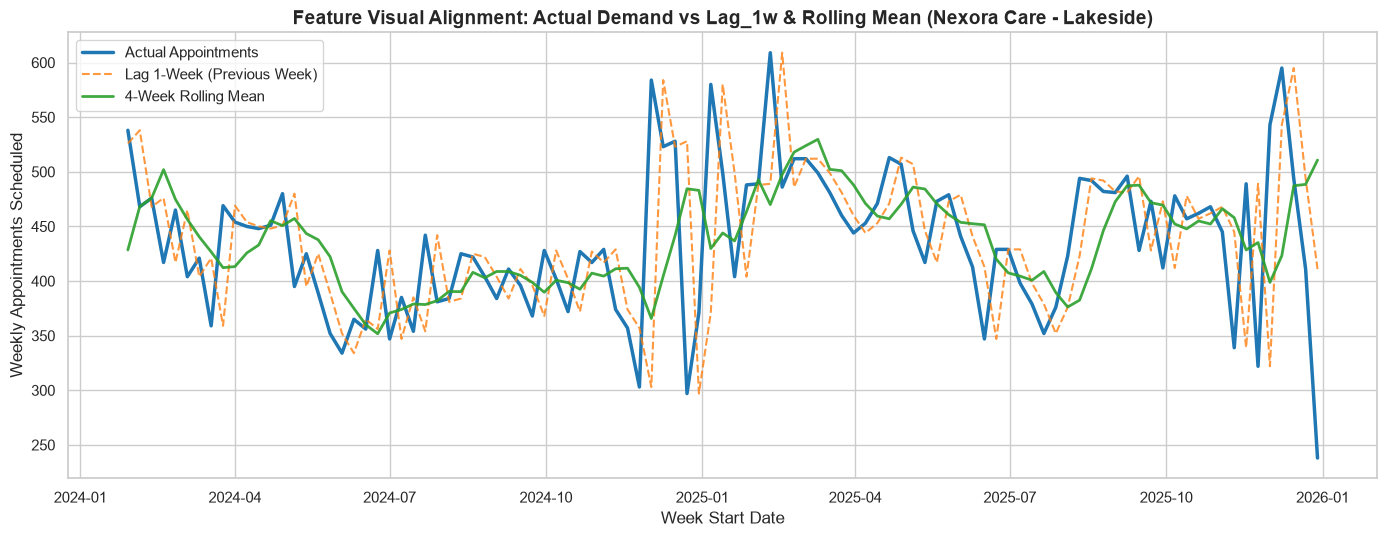

In [26]:
# Plot Actual Volume vs Lag and Rolling Mean
lakeside_df = df_clean[df_clean['ClinicName'] == 'Nexora Care - Lakeside']

plt.figure(figsize=(14, 5.5))
plt.plot(lakeside_df['WeekStart'], lakeside_df['TotalScheduled'], label='Actual Appointments', color='#1f77b4', linewidth=2.5)
plt.plot(lakeside_df['WeekStart'], lakeside_df['lag_1w'], label='Lag 1-Week (Previous Week)', color='#ff7f0e', linestyle='--', alpha=0.8)
plt.plot(lakeside_df['WeekStart'], lakeside_df['rolling_mean_4w'], label='4-Week Rolling Mean', color='#2ca02c', linewidth=2, alpha=0.9)

plt.title('Feature Visual Alignment: Actual Demand vs Lag_1w & Rolling Mean (Nexora Care - Lakeside)', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Weekly Appointments Scheduled')
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()